# TP2 - Métodos No Supervisados usando la EPH
### Taller de Programación (UBA) 2026 - Grupo 8: *Informal self-employed*

Continuación del TP1. Partimos de la base `self_emp` ya limpia, que contiene a los
trabajadores independientes (patrones, cuentapropistas y familiares sin remuneración,
excluyendo el sector público) del 4T2024 y 4T2025, con la variable `informal`
construida según Maurizio & Monsalvo y las dummies del TP1.


## Carga de datos


In [1]:
import pandas as pd
import numpy as np

self_emp = pd.read_parquet('bases/self_emp.parquet')
print("Dimensiones:", self_emp.shape)
self_emp.head()

Dimensiones: (11595, 45)


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,...,asalariado,fam_sin_remun,sector_privado,sector_informal,subocupado,nivel_ed_ord,P21_real,P47T_real,informal,grupo
27,TQRMNORSVHKLKTCDEGJBF00869911,2024,4,1,541,2,66,3.0,1.0,6,...,0,0,1.0,1.0,0.0,6,1.182696e+06,1.971159e+06,0.0,Formal
31,TQRMNOTTRHKOKTCDEFJAH00869619,2024,4,1,350,1,43,1.0,4.0,5,...,0,0,1.0,1.0,0.0,5,7.884637e+05,7.884637e+05,1.0,Informal
35,TQRMNOQSTHKNKUCDEFJAH00869632,2024,4,1,203,2,53,2.0,4.0,3,...,0,0,1.0,1.0,0.0,3,2.891034e+05,4.467961e+05,1.0,Informal
44,TQRMNOSXRHLMLNCDEHIBB00853817,2024,4,1,121,1,60,2.0,1.0,4,...,0,0,1.0,1.0,0.0,4,3.942319e+05,7.227584e+05,1.0,Informal
63,TQRMNORYYHKMKUCDEGJBF00870253,2024,4,1,670,1,47,1.0,4.0,4,...,0,0,1.0,1.0,1.0,4,2.628212e+05,2.628212e+05,1.0,Informal


In [2]:
print(self_emp['ANO4'].value_counts().sort_index())
print(self_emp['informal'].value_counts(dropna=False))

ANO4
2024    5840
2025    5755
Name: count, dtype: int64
informal
1.0    9388
0.0    2154
NaN      53
Name: count, dtype: int64


La base contiene 11.595 observaciones repartidas de forma equilibrada entre ambos
trimestres (5.840 y 5.755), con un 81% de informales según la definición asignada.

## Parte I: Creación de variables y estadística descriptiva

### 1. Creación de variables

#### 1.a) `edad2`, edad al cuadrado

Se incluye el término cuadrático porque la relación entre edad e informalidad no suele
ser lineal: tiende a ser más alta entre los más jóvenes, cae en las edades centrales y
vuelve a subir en los mayores.

In [3]:
self_emp['edad2'] = self_emp['CH06']**2

#### 1.b) `educ`, años de educación formal

Se combinan CH12 (nivel más alto cursado), CH13 (si lo finalizó) y CH14 (último año
aprobado). A los años acumulados antes de cada nivel se le suma la duración completa
del nivel si fue finalizado, o los años aprobados en caso contrario. Se supone primaria
7 años, secundaria 5, terciario 3, universitario 6 y posgrado 4, sin computar el nivel
inicial, de modo que secundario completo equivale a 12 años según la consigna.

In [4]:
for v in ['CH12','CH13','CH14']:
    print(f"--- {v} ---")
    print(self_emp[v].value_counts(dropna=False).sort_index())
    print()

--- CH12 ---
CH12
0       22
1       11
2     1969
3      116
4     5418
5      164
6     1363
7     2376
8      148
9        3
99       5
Name: count, dtype: int64

--- CH13 ---
CH13
0      22
1    7472
2    4098
9       3
Name: count, dtype: int64

--- CH14 ---
CH14
0.0      208
1.0      573
2.0     1079
3.0     1100
4.0      610
5.0      248
6.0       99
7.0       16
8.0       28
9.0        6
98.0       4
99.0     130
NaN     7494
Name: count, dtype: int64



In [5]:
def calcular_educ(row):
    base = {1: 0, 2: 0, 3: 0, 4: 7, 5: 9, 6: 12, 7: 12, 8: 18}
    dur  = {1: 0, 2: 7, 3: 9, 4: 5, 5: 3, 6: 3,  7: 6,  8: 4}
    
    ch12, ch13, ch14 = row['CH12'], row['CH13'], row['CH14']
    
    if ch12 == 0 or ch12 == 9:          # nunca asistió / educación especial
        return 0
    if ch12 not in base:                # CH12 = 99 (Ns/Nr)
        return np.nan
    if ch13 == 1:                       # finalizó el nivel
        return base[ch12] + dur[ch12]
    if ch13 == 2:                       # no lo finalizó
        if pd.isna(ch14) or ch14 >= 98: # Ns/Nr o educación especial
            return np.nan
        return min(base[ch12] + ch14, base[ch12] + dur[ch12])
    return np.nan                       # CH13 = 9

self_emp['educ'] = self_emp.apply(calcular_educ, axis=1)

print(self_emp['educ'].describe())
print("Faltantes:", self_emp['educ'].isna().sum())

count    11462.000000
mean        11.910225
std          3.800962
min          0.000000
25%          9.000000
50%         12.000000
75%         15.000000
max         22.000000
Name: educ, dtype: float64
Faltantes: 133


In [6]:
pd.crosstab(self_emp['CH12'], self_emp['educ'], dropna=False)

educ,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,NaN
CH12,,,,,,,,,,,,,,,,,,,,,
0,22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8,28,46,87,80,65,55,1573,0,0,...,0,0,0,0,0,0,0,0,0,27
3,0,1,2,1,3,0,22,16,28,40,...,0,0,0,0,0,0,0,0,0,3
4,0,0,0,0,0,0,0,54,267,529,...,0,0,0,0,0,0,0,0,0,56
5,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,3
6,0,0,0,0,0,0,0,0,0,0,...,206,998,0,0,0,0,0,0,0,18
7,0,0,0,0,0,0,0,0,0,0,...,269,293,174,51,1305,0,0,0,0,21
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,6,2,4,133,0


In [7]:
print(self_emp.loc[(self_emp['CH12']==4) & (self_emp['CH13']==1), 'educ'].value_counts())

educ
12.0    3461
Name: count, dtype: int64


#### 1.c) `horastrab` horas totales trabajadas

Suma de las horas en la ocupación principal (PP3E_TOT) y en otras ocupaciones (PP3F_TOT).
PP3F_TOT no había sido incluida en la limpieza del TP1, por lo que conserva el código
999 de no respuesta en 2 casos: se reemplaza por NaN antes de sumar. La suma resulta
NaN cuando falta alguno de los dos componentes, ya que en esos casos el total de horas
es desconocido.

In [8]:
print(self_emp['PP3E_TOT'].describe())
print(self_emp['PP3F_TOT'].describe())

count    11566.000000
mean        35.818001
std         18.690697
min          0.000000
25%         20.000000
50%         36.000000
75%         48.000000
max        126.000000
Name: PP3E_TOT, dtype: float64
count    11595.000000
mean         1.119707
std         13.777483
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        999.000000
Name: PP3F_TOT, dtype: float64


In [9]:
print(self_emp.loc[self_emp['PP3F_TOT'] > 126, 'PP3F_TOT'].value_counts())

PP3F_TOT
999.0    2
Name: count, dtype: int64


In [10]:
# 999 es código de no respuesta en PP3F_TOT (2 casos): lo pasamos a NaN antes de sumar
self_emp['PP3F_TOT'] = self_emp['PP3F_TOT'].replace(999, np.nan)

self_emp['horastrab'] = self_emp['PP3E_TOT'] + self_emp['PP3F_TOT']

print(self_emp['horastrab'].describe())

count    11565.000000
mean        36.768526
std         19.165664
min          0.000000
25%         22.000000
50%         40.000000
75%         48.000000
max        131.000000
Name: horastrab, dtype: float64


#### 1.d) `nhogar` cantidad de miembros del hogar

Se calcula sobre la base completa y no sobre `self_emp`, porque esta última contiene
únicamente a los trabajadores independientes, contar filas ahí subestimaría el tamaño
del hogar. El hogar se identifica por CODUSU + NRO_HOGAR, y se agrega ANO4 porque la
EPH es un panel rotativo y una misma vivienda puede aparecer en ambos trimestres.

In [11]:
# nhogar se calcula sobre la base completa (self_emp solo tiene a los independientes)
df24 = pd.read_parquet('bases/df24.parquet')
df25 = pd.read_parquet('bases/df25.parquet')
completa = pd.concat([df24, df25], ignore_index=True)

# Cantidad de miembros por hogar, en cada año
tam_hogar = (completa
             .groupby(['CODUSU', 'NRO_HOGAR', 'ANO4'])['COMPONENTE']
             .count()
             .rename('nhogar')
             .reset_index())

# Lo pegamos a self_emp
self_emp = self_emp.merge(tam_hogar, on=['CODUSU', 'NRO_HOGAR', 'ANO4'], how='left')

print(self_emp['nhogar'].describe())
print("Sin correspondencia:", self_emp['nhogar'].isna().sum())

count    11595.000000
mean         3.458301
std          1.735597
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         19.000000
Name: nhogar, dtype: float64
Sin correspondencia: 0


La construcción de `nhogar` se validó contra la variable IX_TOT de la base de hogares
de la EPH, con coincidencia del 100% de los casos.

In [12]:
hog24 = pd.read_excel('bases/usu_hogar_T424.xlsx', usecols=['CODUSU','NRO_HOGAR','ANO4','IX_TOT'])
comp = tam_hogar.merge(hog24, on=['CODUSU','NRO_HOGAR','ANO4'], how='inner')
print("Coinciden:", (comp['nhogar'] == comp['IX_TOT']).mean())

Coinciden: 1.0


In [13]:
# Diccionario de etiquetas legibles (para tablas y gráficos del informe)
# Se retoma el del TP1 y se amplía con las variables creadas en este TP.

etiquetas = {
    'CH04': 'Sexo',
    'CH06': 'Edad',
    'CH07': 'Estado civil',
    'CH08': 'Cobertura médica',
    'NIVEL_ED': 'Nivel educativo',
    'ESTADO': 'Condición de actividad',
    'CAT_OCUP': 'Categoría ocupacional',
    'EMPLEO': 'Empleo (formal/informal)',
    'SECTOR': 'Sector (formal/informal)',
    'PP04C': 'Tamaño del establecimiento',
    'PP04D_COD': 'Código de ocupación',
    'P21': 'Ingreso ocup. principal',
    'P47T': 'Ingreso total individual',
    'PP05I': 'Aportes jubilat. (independiente)',
    'PP05K': 'Emisión de factura',
    'PP04A': 'Sector estatal/privado',
    'PP3E_TOT': 'Horas ocup. principal',
    'INTENSI': 'Intensidad laboral',
    'AGLOMERADO': 'Aglomerado',
    'PONDIIO': 'Ponderador de ingreso',
    # Variables creadas en el TP2
    'edad2': 'Edad al cuadrado',
    'educ': 'Años de educación',
    'horastrab': 'Horas totales trabajadas',
    'nhogar': 'Miembros del hogar',
    # Ingresos deflactados (TP1)
    'P21_real': 'Ingreso ocup. principal (real 4T2025)',
    'P47T_real': 'Ingreso total individual (real 4T2025)',
    'informal': 'Informalidad (self-employed)',
}

print("Etiquetas definidas:", len(etiquetas))

Etiquetas definidas: 27


### 2. Estadística descriptiva

In [14]:
num_tp1 = ['CH06', 'P21', 'P21_real', 'P47T', 'P47T_real', 'PP04C', 'PP3E_TOT']
num_tp2 = ['edad2', 'educ', 'horastrab', 'nhogar']
numericas = num_tp1 + num_tp2

tabla = (self_emp[numericas].describe().T.round(1)
         .rename(index=etiquetas)
         .rename(columns={'count':'Obs.', 'mean':'Promedio', 'std':'Desvío',
                          'min':'Mín.', '25%':'P25', '50%':'Mediana',
                          '75%':'P75', 'max':'Máx.'}))
tabla

,Obs.,Promedio,Desvío,Mín.,P25,Mediana,P75,Máx.
Edad,11595.0,44.9,14.2,12.0,34.0,45.0,55.0,92.0
Ingreso ocup. principal,8649.0,674100.2,1003093.7,0.0,200000.0,400000.0,800000.0,30000000.0
Ingreso ocup. principal (real 4T2025),8649.0,755650.9,1077176.2,0.0,250000.0,500000.0,919874.3,30000000.0
Ingreso total individual,8439.0,807825.9,1128141.2,0.0,300000.0,500000.0,928000.0,30000000.0
Ingreso total individual (real 4T2025),8439.0,907188.8,1211224.6,0.0,350000.0,600000.0,1050642.5,30000000.0
Tamaño del establecimiento,11486.0,1.6,1.3,1.0,1.0,1.0,2.0,12.0
Horas ocup. principal,11566.0,35.8,18.7,0.0,20.0,36.0,48.0,126.0
Edad al cuadrado,11595.0,2215.6,1329.4,144.0,1156.0,2025.0,3025.0,8464.0
Años de educación,11462.0,11.9,3.8,0.0,9.0,12.0,15.0,22.0
Horas totales trabajadas,11565.0,36.8,19.2,0.0,22.0,40.0,48.0,131.0


In [15]:
self_emp.loc[self_emp['P21'] > 10_000_000, ['CAT_OCUP','P21','PP04C','educ','informal']]

,CAT_OCUP,P21,PP04C,educ,informal
4347,2,15000000.0,2.0,18.0,0.0
6777,2,30000000.0,1.0,15.0,0.0
6796,1,15000000.0,2.0,22.0,1.0
8445,2,11000000.0,1.0,18.0,0.0
8446,1,11000000.0,6.0,12.0,0.0
8755,1,12000000.0,2.0,18.0,1.0
10050,1,20000000.0,6.0,14.0,0.0
11073,2,20000000.0,1.0,18.0,0.0
11255,2,22000000.0,1.0,18.0,0.0


In [16]:
tabla_anio = (self_emp.groupby('ANO4')[numericas]
              .describe()
              .T.round(1)
              .unstack(level=1))
tabla_anio

ANO4         2024                                                            \
            count      mean        std    min       25%       50%       75%   
CH06       5840.0      44.6       14.2   15.0      33.0      44.0      55.0   
P21        4340.0  517401.6   688877.8    0.0  150000.0  320000.0  600000.0   
P21_real   4340.0  679920.7   905258.6    0.0  197115.9  420514.0  788463.7   
P47T       4241.0  629463.6   776167.6    0.0  240000.0  430000.0  730000.0   
P47T_real  4241.0  827182.1  1019966.6    0.0  315385.5  565065.7  959297.5   
PP04C      5781.0       1.7        1.3    1.0       1.0       1.0       2.0   
PP3E_TOT   5825.0      35.7       18.6    0.0      20.0      36.0      48.0   
edad2      5840.0    2193.1     1325.2  225.0    1089.0    1936.0    3025.0   
educ       5780.0      12.0        3.8    0.0      10.0      12.0      15.0   
horastrab  5824.0      36.6       19.1    0.0      22.0      40.0      48.0   
nhogar     5840.0       3.4        1.7    1.0       2.0       3.0       4.0   

ANO4                     2025                                                  \
                  max   count      mean        std    min       25%       50%   
CH06             92.0  5755.0      45.1       14.2   12.0      34.0      45.0   
P21        15000000.0  4309.0  831926.0  1221576.4    0.0  280000.0  500000.0   
P21_real   19711593.0  4309.0  831926.0  1221576.4    0.0  280000.0  500000.0   
P47T       16500000.0  4198.0  988015.1  1373141.3    0.0  400000.0  650000.0   
P47T_real  21682752.2  4198.0  988015.1  1373141.3    0.0  400000.0  650000.0   
PP04C            12.0  5705.0       1.6        1.3    1.0       1.0       1.0   
PP3E_TOT        126.0  5741.0      35.9       18.7    0.0      20.0      36.0   
edad2          8464.0  5755.0    2238.4     1333.4  144.0    1156.0    2025.0   
educ             22.0  5682.0      11.8        3.8    0.0       9.0      12.0   
horastrab       126.0  5741.0      36.9       19.3    0.0      23.0      40.0   
nhogar           19.0  5755.0       3.5        1.7    1.0       2.0       3.0   

ANO4                              
                 75%         max  
CH06            56.0        90.0  
P21        1000000.0  30000000.0  
P21_real   1000000.0  30000000.0  
P47T       1100000.0  30000000.0  
P47T_real  1100000.0  30000000.0  
PP04C            2.0        11.0  
PP3E_TOT        48.0       112.0  
edad2         3136.0      8100.0  
educ            15.0        22.0  
horastrab       48.0       131.0  
nhogar           4.0        14.0

In [17]:
comp = pd.DataFrame({
    '2024': self_emp[self_emp['ANO4']==2024][numericas].median(),
    '2025': self_emp[self_emp['ANO4']==2025][numericas].median(),
}).round(1)
comp['Var. %'] = ((comp['2025']/comp['2024'] - 1)*100).round(1)
comp.rename(index=etiquetas)

,2024,2025,Var. %
Edad,44.0,45.0,2.3
Ingreso ocup. principal,320000.0,500000.0,56.2
Ingreso ocup. principal (real 4T2025),420514.0,500000.0,18.9
Ingreso total individual,430000.0,650000.0,51.2
Ingreso total individual (real 4T2025),565065.7,650000.0,15.0
Tamaño del establecimiento,1.0,1.0,0.0
Horas ocup. principal,36.0,36.0,0.0
Edad al cuadrado,1936.0,2025.0,4.6
Años de educación,12.0,12.0,0.0
Horas totales trabajadas,40.0,40.0,0.0


### 3. Matriz de correlaciones

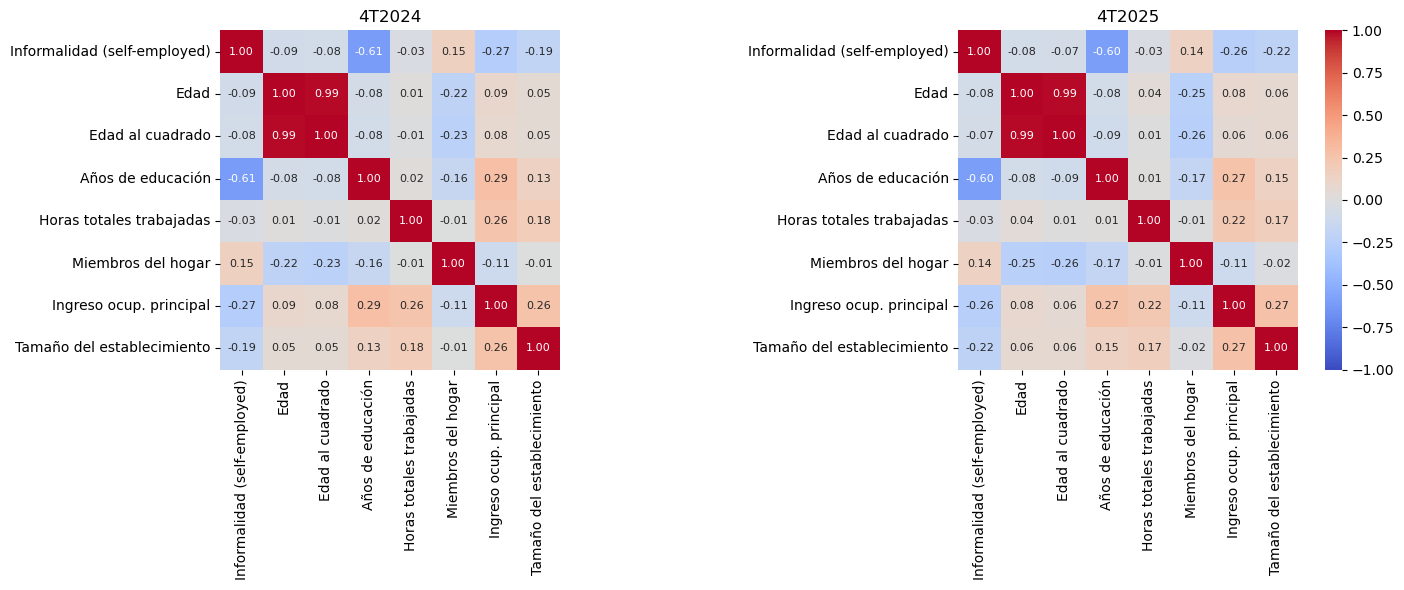

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables del inciso 3 (edad = CH06)
vars_corr = ['informal', 'CH06', 'edad2', 'educ', 'horastrab', 'nhogar', 'P21', 'PP04C']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, anio in zip(axes, [2024, 2025]):
    corr = self_emp.loc[self_emp['ANO4'] == anio, vars_corr].corr()
    corr.index = [etiquetas.get(v, v) for v in corr.index]
    corr.columns = [etiquetas.get(v, v) for v in corr.columns]

    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, ax=ax,
                cbar=(anio == 2025), annot_kws={'size': 8})
    ax.set_title(f'4T{anio}')

plt.tight_layout()
plt.show()

In [19]:
c24 = self_emp.loc[self_emp['ANO4']==2024, vars_corr].corr()
c25 = self_emp.loc[self_emp['ANO4']==2025, vars_corr].corr()

# Cambio de cada correlación con informal entre años
pd.DataFrame({'2024': c24['informal'], '2025': c25['informal']}).round(3)

,2024,2025
informal,1.000,1.000
CH06,-0.092,-0.085
edad2,-0.085,-0.072
educ,-0.611,-0.601
horastrab,-0.033,-0.034
nhogar,0.150,0.138
P21,-0.266,-0.256
PP04C,-0.189,-0.218


In [20]:
print(self_emp['CAT_OCUP'].value_counts().sort_index())

for cat, nombre in [(1,'Patrón'), (2,'Cuenta propia'), (4,'Fam. sin remun.')]:
    sub = self_emp[self_emp['CAT_OCUP']==cat].dropna(subset=['educ','informal'])
    if sub['informal'].nunique() > 1:
        r = sub[['educ','informal']].corr().iloc[0,1]
        print(f"{nombre:18} n={len(sub):5}  corr(educ, informal) = {r:.3f}")
    else:
        print(f"{nombre:18} n={len(sub):5}  informal constante")

CAT_OCUP
1    1478
2    9933
4     184
Name: count, dtype: int64
Patrón             n= 1411  corr(educ, informal) = -0.208
Cuenta propia      n= 9816  corr(educ, informal) = -0.674
Fam. sin remun.    n=  182  informal constante


La correlación entre años de educación e informalidad (-0,61) es la más alta de la
matriz, pero está en parte determinada por construcción: en la definición de Maurizio
& Monsalvo, un cuentapropista se considera formal si alcanzó el nivel universitario
completo. Al desagregar por categoría ocupacional, la correlación es -0,67 entre
cuentapropistas (85% de la muestra) y solo -0,21 entre patrones, cuyo criterio de
formalidad depende del tamaño del establecimiento. Esta advertencia debe tenerse
presente al interpretar los resultados de la Parte II.

## Parte II: Métodos No Supervisados

### A. Análisis de Componentes Principales (PCA)

PCA busca reducir la dimensionalidad: construye combinaciones lineales de las
variables originales, las componentes principales, que concentren la mayor varianza
posible, de modo que unas pocas componentes resuman la información de todas. Esto
permite visualizar en dos dimensiones una estructura que originalmente tiene siete.

Se aplica a las siete variables numéricas indicadas en la consigna: edad, edad²,
años de educación, horas totales trabajadas, miembros del hogar, ingreso de la
ocupación principal y tamaño del establecimiento. La variable `informal` no participa
del análisis, ya que PCA es un método no supervisado; se emplea únicamente para
colorear los gráficos y evaluar a posteriori si las componentes captan algún patrón
asociado a la informalidad.

Las variables se estandarizan previamente (media 0, desvío 1) porque PCA maximiza
varianza y esta depende de las unidades de medida: sin estandarizar, el ingreso
dominaría el análisis por su escala.

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Las 7 variables del enunciado (edad = CH06)
vars_pca = ['CH06', 'edad2', 'educ', 'horastrab', 'nhogar', 'P21', 'PP04C']

# PCA no admite faltantes: nos quedamos con los casos completos
datos = self_emp[vars_pca + ['informal']].dropna()

print("Casos completos:", len(datos), "de", len(self_emp))
print(datos['informal'].value_counts(normalize=True).round(3))

Casos completos: 8520 de 11595
informal
1.0    0.825
0.0    0.175
Name: proportion, dtype: float64


El análisis de la Parte II se realiza sobre 8.520 casos completos (de 11.595), ya que
PCA y los algoritmos de clustering no admiten valores faltantes. La pérdida se explica
principalmente por la no respuesta en ingresos (P21). La composición de la submuestra
es equivalente a la original (82,5% de informales frente a 81,3%), por lo que no se
observa un sesgo de selección relevante.

In [22]:
# Separamos las 7 variables (X) de la variable de grupo, que solo se usa para colorear
X = datos[vars_pca]
grupo = datos['informal']

# Estandarizamos: media 0 y desvío 1
scaler = StandardScaler(with_std=True, with_mean=True)
X_transformed = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# PCA sobre las variables estandarizadas
pca = PCA()
scores = pca.fit_transform(X_transformed)

print("Dimensiones de los scores:", scores.shape)

Dimensiones de los scores: (8520, 7)


#### 1. Scores del primer y segundo componente

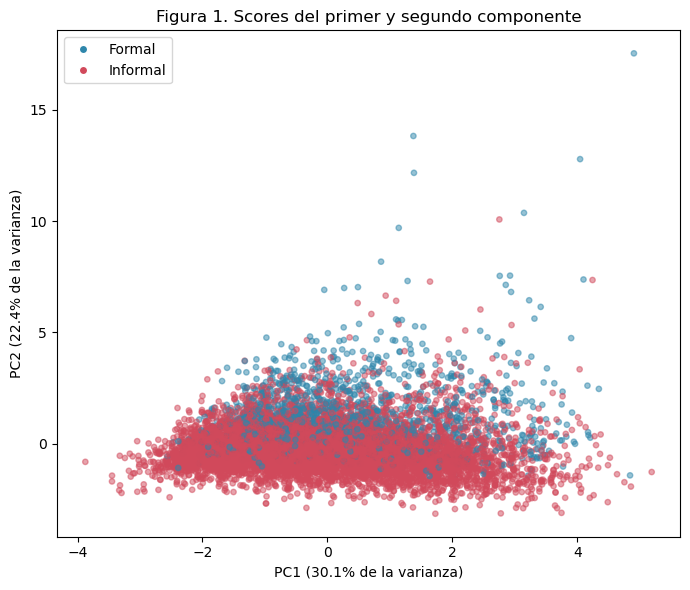

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

# Un color para formales y otro para informales
colores = np.where(grupo == 1, "#d1495b", "#2e86ab")
ax.scatter(scores[:, 0], scores[:, 1], c=colores, alpha=0.5, s=15)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de la varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de la varianza)")
ax.set_title("Figura 1. Scores del primer y segundo componente")

# Leyenda manual (porque coloreamos con un array, no con seaborn)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#2e86ab", label='Formal'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#d1495b", label='Informal')
])

plt.tight_layout()
plt.show()

In [24]:
# Distancia al origen en el plano PC1-PC2
dist = np.sqrt(scores[:, 0]**2 + scores[:, 1]**2)
idx_out = np.argsort(dist)[-10:]   # los 10 más alejados

datos.iloc[idx_out]

,CH06,edad2,educ,horastrab,nhogar,P21,PP04C,informal
8446,40,1600,12.0,60.0,4,11000000.0,6.0,0.0
7471,73,5329,22.0,40.0,2,6000000.0,10.0,0.0
8755,71,5041,18.0,40.0,2,12000000.0,2.0,1.0
295,40,1600,18.0,40.0,2,10000000.0,10.0,0.0
6796,55,3025,22.0,50.0,2,15000000.0,2.0,1.0
4347,62,3844,18.0,112.0,5,15000000.0,2.0,0.0
11073,34,1156,18.0,40.0,2,20000000.0,1.0,0.0
11255,58,3364,18.0,24.0,1,22000000.0,1.0,0.0
10050,32,1024,14.0,58.0,3,20000000.0,6.0,0.0
6777,58,3364,15.0,54.0,2,30000000.0,1.0,0.0


Los casos atípicos identificados en el plano PC1-PC2 corresponden casi exclusivamente
a observaciones con ingresos de la ocupación principal muy elevados (entre 6 y 30
millones de pesos, frente a una mediana de 400 mil), en su mayoría profesionales
independientes con educación universitaria o de posgrado completa. La ausencia de
un tope en la distribución de ingresos explica que esta variable genere los valores
extremos del análisis.

#### 2. Loadings (ponderadores) de las variables

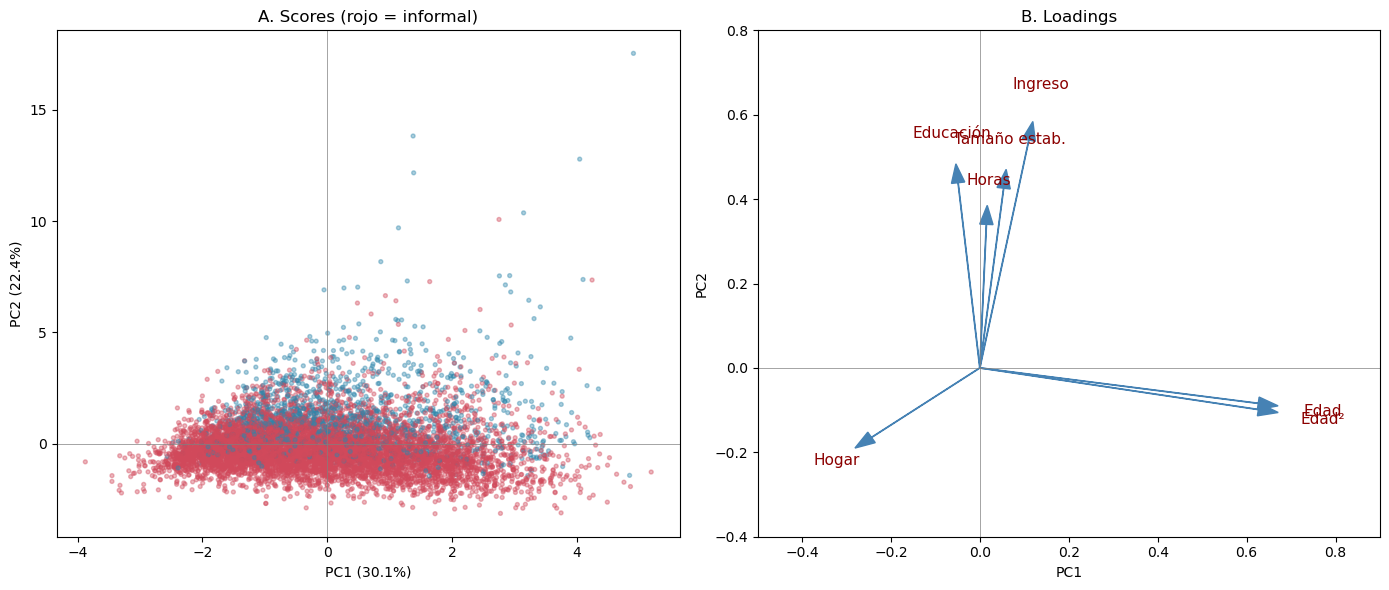

In [25]:
loadings = pca.components_.T

# Etiquetas cortas para que no se pisen
cortas = {'CH06':'Edad', 'edad2':'Edad²', 'educ':'Educación',
          'horastrab':'Horas', 'nhogar':'Hogar',
          'P21':'Ingreso', 'PP04C':'Tamaño estab.'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: scores
ax1.scatter(scores[:, 0], scores[:, 1], c=colores, alpha=0.4, s=8)
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax1.set_title("A. Scores (rojo = informal)")
ax1.axhline(0, color='gray', lw=.5); ax1.axvline(0, color='gray', lw=.5)

# Panel B: loadings
for i, var in enumerate(vars_pca):
    ax2.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              color='steelblue', head_width=0.03, length_includes_head=True)
    ax2.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, cortas[var],
             color='darkred', fontsize=11, ha='center', va='center')

ax2.set_xlim(-0.5, 0.9); ax2.set_ylim(-0.4, 0.8)
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
ax2.set_title("B. Loadings")
ax2.axhline(0, color='gray', lw=.5); ax2.axvline(0, color='gray', lw=.5)

plt.tight_layout(); plt.show()

In [26]:
pd.DataFrame(loadings[:, :2],
             index=[etiquetas.get(v, v) for v in vars_pca],
             columns=['PC1', 'PC2']).round(3)

,PC1,PC2
Edad,0.671,-0.090
Edad al cuadrado,0.671,-0.106
Años de educación,-0.054,0.484
Horas totales trabajadas,0.017,0.385
Miembros del hogar,-0.281,-0.190
Ingreso ocup. principal,0.119,0.584
Tamaño del establecimiento,0.059,0.471


#### 3. Proporción de varianza explicada


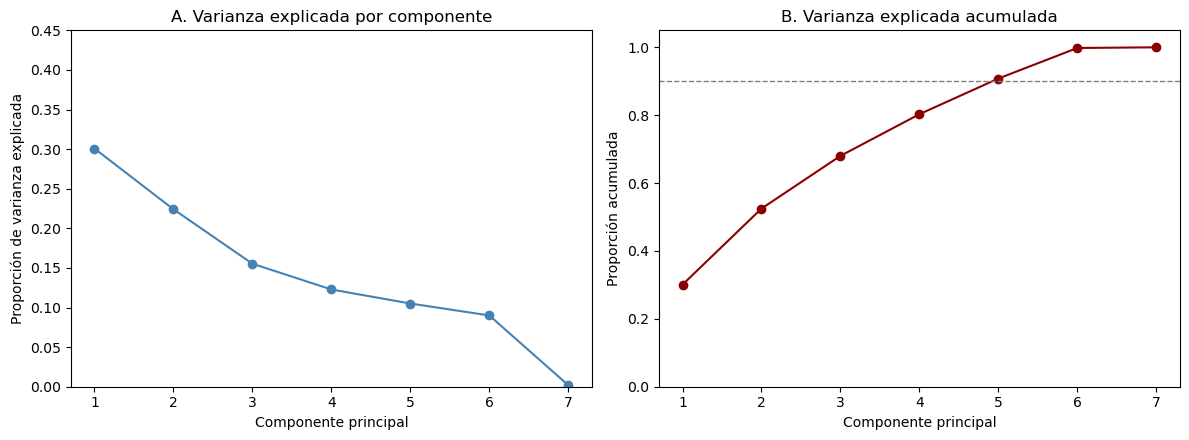

PVE por componente: [0.301 0.224 0.155 0.123 0.105 0.09  0.002]
PVE acumulada:      [0.301 0.525 0.68  0.803 0.908 0.998 1.   ]


In [27]:
pve = pca.explained_variance_ratio_
comp = np.arange(1, len(pve) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(comp, pve, 'o-', color='steelblue')
ax1.set_xlabel("Componente principal")
ax1.set_ylabel("Proporción de varianza explicada")
ax1.set_title("A. Varianza explicada por componente")
ax1.set_ylim(0, 0.45)

ax2.plot(comp, np.cumsum(pve), 'o-', color='darkred')
ax2.axhline(0.9, ls='--', color='gray', lw=1)
ax2.set_xlabel("Componente principal")
ax2.set_ylabel("Proporción acumulada")
ax2.set_title("B. Varianza explicada acumulada")
ax2.set_ylim(0, 1.05)

plt.tight_layout(); plt.show()

print("PVE por componente:", pve.round(3))
print("PVE acumulada:     ", np.cumsum(pve).round(3))

La varianza se distribuye de manera relativamente pareja entre las primeras seis
componentes (30,1%, 22,4%, 15,5%, 12,3%, 10,5% y 9,0%), sin que se observe un codo
definido. Se requieren cinco componentes para alcanzar el 90% de la varianza, lo que
confirma el contexto de correlaciones bajas identificado en la Parte I: al no haber
redundancia entre los predictores, PCA no logra una reducción sustantiva de la
dimensionalidad. La única excepción es el par edad–edad², cuya correlación de 0,99
hace que la séptima componente explique apenas un 0,2% de la varianza.

### B. Clustering

#### 4. Clúster k-medias

Se aplica el algoritmo sobre las mismas siete variables estandarizadas. La
estandarización es necesaria porque k-medias se basa en distancias euclídeas.

##### a) Aplicación con k=2

In [28]:
from sklearn.cluster import KMeans

# Sobre las mismas variables estandarizadas que usamos en PCA
kmeans2 = KMeans(n_clusters=2, random_state=10, init="random", n_init=20).fit(X_transformed)

# n_clusters: número de clusters
# random_state: semilla (para poder reproducir los resultados)
# n_init: cuántas veces se ejecuta el algoritmo con distintas semillas de centroides;
#         el resultado final es el de menor inertia

datos['cluster'] = kmeans2.labels_
print(datos['cluster'].value_counts())

cluster
0    5148
1    3372
Name: count, dtype: int64


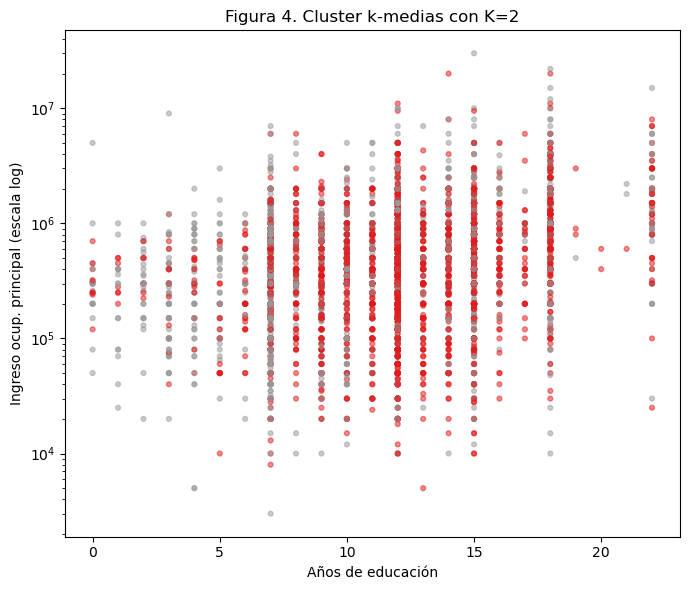

cluster,0,1
informal,,
0.0,876,617
1.0,4272,2755


In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(datos['educ'], datos['P21'], c=datos['cluster'], cmap='Set1', alpha=0.5, s=12)
ax.set_yscale('log')
ax.set_xlabel("Años de educación")
ax.set_ylabel("Ingreso ocup. principal (escala log)")
ax.set_title("Figura 4. Cluster k-medias con K=2")
plt.tight_layout(); plt.show()

pd.crosstab(datos['informal'], datos['cluster'],
            rownames=['informal'], colnames=['cluster'])

In [30]:
# Perfil promedio de cada cluster
datos.groupby('cluster')[vars_pca].mean().round(1)

,CH06,edad2,educ,horastrab,nhogar,P21,PP04C
cluster,,,,,,,
0,35.2,1308.1,12.3,36.5,3.9,619890.0,1.6
1,58.7,3504.1,11.1,36.0,2.8,755518.5,1.7


El algoritmo con k=2 no logra separar a formales de informales. La proporción de
informales es prácticamente idéntica en ambos grupos (83,0% y 81,7%, frente al 82,5%
del total), lo que indica que la partición es independiente de la condición de
informalidad. El perfil promedio de cada clúster muestra que la variable que
efectivamente separa es la edad (35,2 años en el clúster 0 frente a 58,7 en el
clúster 1), mientras que el resto de las variables presenta valores similares. Este
resultado es consistente con el análisis de PCA, donde la primera componente también
resultó dominada por la edad. Cabe señalar que edad y edad² ingresan como dos de las
siete variables y presentan una correlación de 0,99, por lo que la dimensión etaria
recibe un peso duplicado en el cálculo de distancias.

##### b) Método del codo (k=1 a k=40)

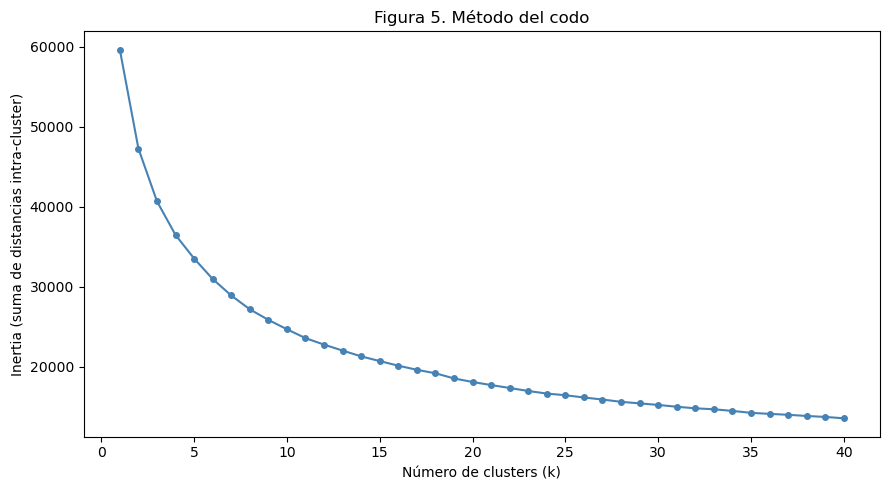

In [31]:
n_cluster_range = range(1, 41)
inertia_values = []

for n_clusters in n_cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=10, init="random", n_init=20)
    kmeans.fit(X_transformed)
    inertia_values.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_cluster_range, inertia_values, 'o-', color='steelblue', ms=4)
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inertia (suma de distancias intra-cluster)")
ax.set_title("Figura 5. Método del codo")
plt.tight_layout(); plt.show()

La curva de inertia decrece de forma suave y continua, sin presentar un codo
claramente definido. La mayor reducción se concentra en los primeros valores de k
(entre 3 y 5), pero a partir de allí la disminución es gradual y sin quiebres. Esta
ausencia de un k óptimo evidente es consistente con los resultados de PCA: al no
existir una estructura de correlación marcada entre los predictores, los datos no
presentan agrupamientos naturales bien delimitados.

In [32]:
caidas = pd.DataFrame({
    'k': list(n_cluster_range)[1:],
    'inertia': inertia_values[1:],
    'caida_abs': np.diff(inertia_values).round(0),
    'caida_%': (np.diff(inertia_values) / np.array(inertia_values[:-1]) * 100).round(1)
})
caidas.head(12)

,k,inertia,caida_abs,caida_%
0,2,47286.579466,-12353.0,-20.7
1,3,40692.170674,-6594.0,-13.9
2,4,36480.697074,-4211.0,-10.3
3,5,33540.104523,-2941.0,-8.1
4,6,30981.039342,-2559.0,-7.6
5,7,28919.271593,-2062.0,-6.7
6,8,27188.435272,-1731.0,-6.0
7,9,25869.525290,-1319.0,-4.9
8,10,24694.801084,-1175.0,-4.5
9,11,23585.602779,-1109.0,-4.5


Las reducciones porcentuales de la inertia son de -20,7%, -13,9% y -10,3% al pasar
a k=2, 3 y 4 respectivamente, y a partir de k=5 se ubican por debajo del 8% con
variaciones cada vez más parejas. Por inspección visual, el codo se ubicaría entre
k=4 y k=5, aunque el quiebre no es nítido. Esta ambigüedad es consistente con lo
observado en PCA: al no existir una estructura de correlación marcada entre los
predictores, los datos no presentan agrupamientos naturales bien delimitados.

#### 5. Clúster jerárquico

A diferencia de k-medias, el clustering jerárquico no requiere fijar el número de
grupos de antemano: parte de cada observación como un grupo individual y los va
fusionando de a pares según su similitud, hasta llegar a un único grupo. El resultado
se representa en un **dendrograma**, un diagrama en forma de árbol donde la altura a
la que se unen dos ramas indica cuán distintas son entre sí: cuanto más abajo se
fusionan, más parecidas. El número de clústeres se obtiene "cortando" el árbol a una
altura determinada.

Se utiliza el criterio de enlace de Ward, que fusiona los grupos que menos aumentan
la variación intra-clúster, y distancia euclídea sobre las variables estandarizadas.

El análisis se realiza sobre una submuestra aleatoria de 300 observaciones: con las
8.520 observaciones completas, el algoritmo requiere calcular más de 36 millones de
distancias y el dendrograma resultante sería ilegible.

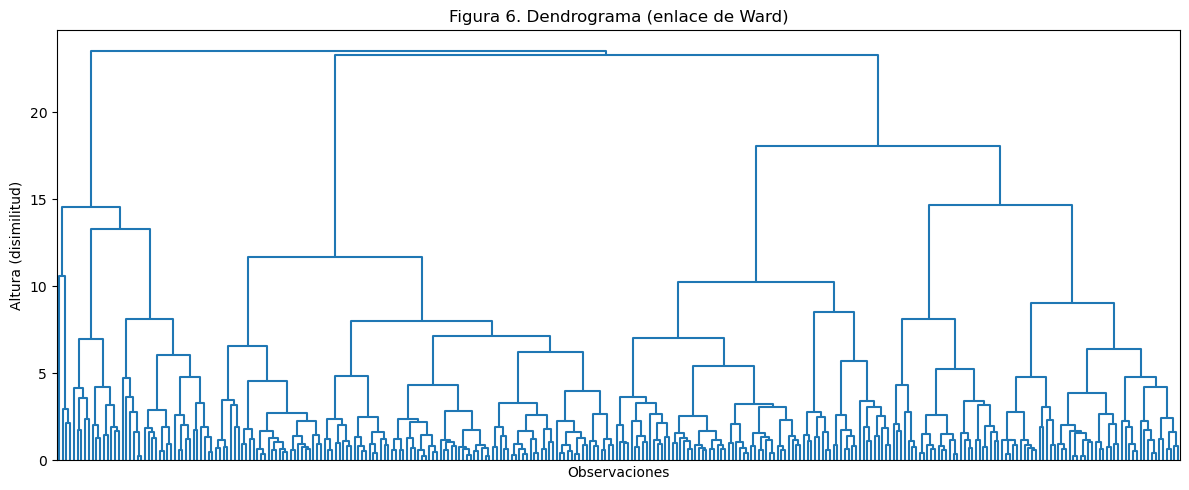

In [33]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Submuestra aleatoria: el dendrograma con 8.520 observaciones sería ilegible
np.random.seed(10)
idx = np.random.choice(len(X_transformed), size=300, replace=False)
X_sub = X_transformed.iloc[idx]

# Enlace de Ward sobre las variables estandarizadas
Z = linkage(X_sub, method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, no_labels=True, color_threshold=0)
ax.set_title("Figura 6. Dendrograma (enlace de Ward)")
ax.set_xlabel("Observaciones")
ax.set_ylabel("Altura (disimilitud)")
plt.tight_layout(); plt.show()

In [34]:
from scipy.cluster.hierarchy import fcluster

# Cortamos el árbol en 2 grupos
grupos_jer = fcluster(Z, t=2, criterion='maxclust')

# Las mismas 300 observaciones de la submuestra
sub = datos.iloc[idx].copy()
sub['cluster_jer'] = grupos_jer

print(pd.crosstab(sub['informal'], sub['cluster_jer'],
                  rownames=['informal'], colnames=['cluster jerárquico']))

# Perfil promedio de cada grupo
sub.groupby('cluster_jer')[vars_pca].mean().round(1)

cluster jerárquico   1    2
informal                   
0.0                 21   25
1.0                 21  233


,CH06,edad2,educ,horastrab,nhogar,P21,PP04C
cluster_jer,,,,,,,
1,41.1,1906.1,15.0,38.8,2.8,1467023.8,4.1
2,44.3,2149.8,11.1,35.4,3.5,477620.2,1.2


In [35]:
# Chequeamos con otras submuestras
for semilla in [1, 42, 99]:
    np.random.seed(semilla)
    i = np.random.choice(len(X_transformed), size=300, replace=False)
    Zi = linkage(X_transformed.iloc[i], method="ward")
    g = fcluster(Zi, t=2, criterion='maxclust')
    s = datos.iloc[i].copy(); s['g'] = g
    prop = s.groupby('g')['informal'].mean().round(3)
    tam = s['g'].value_counts().sort_index().values
    print(f"semilla {semilla}: prop. informales por grupo {prop.values}, tamaños {tam}")

semilla 1: prop. informales por grupo [0.842 0.752], tamaños [183 117]
semilla 42: prop. informales por grupo [0.787 0.831], tamaños [122 178]
semilla 99: prop. informales por grupo [0.893 0.828], tamaños [ 56 244]


In [36]:
#con una muestra más grande
np.random.seed(10)
idx2 = np.random.choice(len(X_transformed), size=2000, replace=False)
Z2 = linkage(X_transformed.iloc[idx2], method="ward")

g2 = fcluster(Z2, t=2, criterion='maxclust')
sub2 = datos.iloc[idx2].copy()
sub2['cluster_jer'] = g2

print(pd.crosstab(sub2['informal'], sub2['cluster_jer'],
                  rownames=['informal'], colnames=['cluster jerárquico']))
print(sub2.groupby('cluster_jer')[vars_pca].mean().round(1))

cluster jerárquico    1    2
informal                    
0.0                 192  155
1.0                 907  746
             CH06   edad2  educ  horastrab  nhogar       P21  PP04C
cluster_jer                                                        
1            35.5  1343.1  12.9       36.2     3.6  603476.8    1.4
2            55.7  3224.1  10.7       37.1     3.2  800040.0    1.9


Al cortar el dendrograma en dos grupos, la proporción de informales resulta
prácticamente idéntica en ambos (82,5% y 82,8%, frente al 82,5% del total), por lo
que el clustering jerárquico tampoco logra separar formales de informales. El perfil
promedio muestra que la partición responde nuevamente a la edad (35,5 años frente a
55,7), replicando el resultado de k-medias y la primera componente del PCA.

Cabe señalar que con una submuestra de 300 observaciones el resultado era inestable:
la composición de los grupos variaba sustancialmente según la submuestra sorteada.
Por ello el análisis se realizó sobre 2.000 observaciones, verificando el resultado.

#### 6. Clúster k-modas

A diferencia de k-medias, k-modas trabaja con variables categóricas: usa modas en lugar
de medias y cuenta desacuerdos en lugar de distancias euclídeas. Se aplica a las dummies
construidas en el TP1 y a las variables numéricas categorizadas en tramos, excluyendo la
variable objetivo `informal`.

##### a) Aplicación con k=2

In [37]:
# Dummies creadas en el TP1
dummies = ['mujer', 'en_pareja', 'sin_cobertura', 'patron', 'cuenta_propia',
           'asalariado', 'fam_sin_remun', 'sector_privado', 'sector_informal',
           'subocupado']

# Verificamos cuáles existen realmente en la base
print([d for d in dummies if d not in self_emp.columns])

[]


In [38]:
# Categorizamos las numéricas en tramos
cat = pd.DataFrame(index=self_emp.index)

cat['edad_cat']  = pd.cut(self_emp['CH06'], [17, 30, 45, 60, 100],
                          labels=['18-30', '31-45', '46-60', '60+'])
cat['educ_cat']  = pd.cut(self_emp['educ'], [-1, 7, 12, 18, 25],
                          labels=['hasta primaria', 'secundaria', 'superior', 'posgrado'])
cat['horas_cat'] = pd.cut(self_emp['horastrab'], [-1, 20, 35, 45, 150],
                          labels=['<20', '20-35', '35-45', '45+'])
cat['hogar_cat'] = pd.cut(self_emp['nhogar'], [0, 2, 4, 20],
                          labels=['1-2', '3-4', '5+'])

# Sumamos las dummies del TP1
X_cat = pd.concat([self_emp[dummies], cat], axis=1)

# k-modes no admite faltantes
X_cat = X_cat.dropna().astype(str)
print("Observaciones:", len(X_cat), "| Variables:", X_cat.shape[1])
X_cat.head()

Observaciones: 11346 | Variables: 14


,mujer,en_pareja,sin_cobertura,patron,cuenta_propia,asalariado,fam_sin_remun,sector_privado,sector_informal,subocupado,edad_cat,educ_cat,horas_cat,hogar_cat
0,1,0.0,0.0,0,1,0,0,1.0,1.0,0.0,60+,superior,<20,1-2
1,0,1.0,1.0,0,1,0,0,1.0,1.0,0.0,31-45,superior,20-35,3-4
2,1,1.0,1.0,0,1,0,0,1.0,1.0,0.0,46-60,secundaria,45+,3-4
3,0,1.0,0.0,0,1,0,0,1.0,1.0,0.0,46-60,secundaria,20-35,3-4
4,0,1.0,1.0,0,1,0,0,1.0,1.0,1.0,46-60,secundaria,<20,5+


In [39]:
# instalación kmodes
!pip install kmodes

In [40]:
from kmodes.kmodes import KModes

km = KModes(n_clusters=2, init="Huang", n_init=5, random_state=42, verbose=1)
labels = km.fit_predict(X_cat)

# init: método de iniciación (Huang es más eficiente para bases grandes)
# n_init: varias iteraciones iniciales, porque hay aleatorización en el paso inicial
# random_state: semilla para que sea replicable

# Comparamos contra informalidad (solo los casos que entraron al algoritmo)
comp_modes = self_emp.loc[X_cat.index, ['informal']].copy()
comp_modes['cluster_modes'] = labels

print(pd.crosstab(comp_modes['informal'], comp_modes['cluster_modes'],
                  rownames=['informal'], colnames=['cluster k-modes']))

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 3209, cost: 43252.0
Run 1, iteration: 2/100, moves: 1278, cost: 43252.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 2581, cost: 44923.0
Run 2, iteration: 2/100, moves: 2110, cost: 43462.0
Run 2, iteration: 3/100, moves: 1423, cost: 42241.0
Run 2, iteration: 4/100, moves: 356, cost: 42241.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 2482, cost: 43378.0
Run 3, iteration: 2/100, moves: 534, cost: 43378.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 1493, cost: 45817.0
Run 4, iteration: 2/100, moves: 934, cost: 45448.0
Run 4, iteration: 3/100, moves: 119, cost: 45448.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 

In [41]:
modas = pd.DataFrame(km.cluster_centroids_, columns=X_cat.columns)
modas.index.name = 'cluster'
modas

,mujer,en_pareja,sin_cobertura,patron,cuenta_propia,asalariado,fam_sin_remun,sector_privado,sector_informal,subocupado,edad_cat,educ_cat,horas_cat,hogar_cat
cluster,,,,,,,,,,,,,,
0,0,1.0,0.0,0,1,0,0,1.0,0.0,0.0,46-60,superior,45+,1-2
1,0,1.0,1.0,0,1,0,0,1.0,1.0,0.0,31-45,secundaria,<20,3-4


##### b) Método del codo y comparación con k-medias

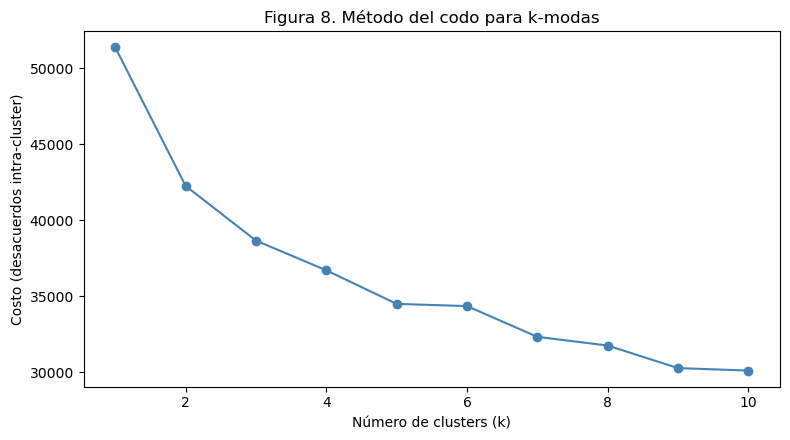

In [42]:
costos = []
ks = range(1, 11)
for k in ks:
    kmodes_k = KModes(n_clusters=k, init="Huang", n_init=5, random_state=42, verbose=0)
    kmodes_k.fit(X_cat)
    costos.append(kmodes_k.cost_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(ks), costos, 'o-', color='steelblue')
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Costo (desacuerdos intra-cluster)")
ax.set_title("Figura 8. Método del codo para k-modas")
plt.tight_layout(); plt.show()

In [43]:
caidas_modes = pd.DataFrame({
    'k': list(ks)[1:],
    'costo': costos[1:],
    'caida_%': (np.diff(costos) / np.array(costos[:-1]) * 100).round(1)
})
caidas_modes

,k,costo,caida_%
0,2,42241.0,-17.7
1,3,38649.0,-8.5
2,4,36694.0,-5.1
3,5,34487.0,-6.0
4,6,34341.0,-0.4
5,7,32319.0,-5.9
6,8,31747.0,-1.8
7,9,30263.0,-4.7
8,10,30100.0,-0.5


A diferencia de k-medias, donde la curva de inertia descendía de forma suave sin un
quiebre identificable, el costo de k-modas muestra un codo más definido en k=2: la
reducción al pasar de uno a dos clústeres es de aproximadamente 18%, mientras que los
incrementos posteriores producen caídas sensiblemente menores. Esto sugiere que las
variables categóricas, que incorporan cobertura médica, sector informal y categoría
ocupacional, delimitan una estructura de dos grupos más marcada que la que surge de
las siete variables numéricas.